In [9]:
from itertools import product
from pathlib import Path

import jsonlines
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
from torchmetrics.classification import BinaryF1Score

from heisenberg_hamiltonians import HeisenbergJ1J2
from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    AmplitudeSignalKind,
    LatticeBooleanAnalyzer,
    LBFFromNN,
#    LBFFromSpinSystemGS,
    SignalKind,
    SignSignalKind,
    LBFFromSpinSystem,
    ValueSignalKind,get_scorer
)
from pytorchtools import EarlyStopping
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangularLattice
from spin_nn import FC1SpinNN, SpinNN
from misc_utils import make_unpacked_configurations
from fast_boolean_analysis import fourier_expand, FourierSeries, keep_largest_n
import matplotlib.pyplot as plt
import time
from scipy.optimize import curve_fit



In [3]:
def plot_coeffs(system, terms):
    signal = LBFFromSpinSystem(
        system=system,
        kind=SignSignalKind(),
    )

    fourier = fourier_expand(signal)
    coeffs = fourier.coeffs / np.sqrt((fourier.coeffs**2).sum())
    plt.plot(
        np.abs(coeffs[np.argsort(-np.abs(coeffs))])[:terms],
        label=system.lattice.__class__.__name__,
    )

    ground_state = system.get_ground_state_coeffs(system.canonical_basis.states)
    plt.plot(
        np.abs(ground_state[np.argsort(-np.abs(ground_state))])[:terms],
        label=system.lattice.__class__.__name__ + "_ground_state",
    )

In [13]:
benchmark_results = pd.Series(dtype='float64')

# Loop over n values
for n in [2, 3, 4]:
    # Start timer
    start_time = time.time()
    
    lattice = KagomeLattice(width=2, height=n)
    system = HeisenbergJ1J2(lattice=lattice, J1=1, J2=1, use_symmetries=False, spin_inversion=None)
    signal = LBFFromSpinSystem(system=system, kind=SignSignalKind())
    for _ in range(40):
        fourier = fourier_expand(signal)
    
    # Stop timer
    end_time = time.time()
    
    # Record elapsed time
    elapsed_time = end_time - start_time
    benchmark_results.loc[n] = elapsed_time
benchmark_results


2023-10-19 18:36:12.324 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=12
2023-10-19 18:36:12.325 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 0 elements
2023-10-19 18:36:12.326 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-10-19 18:36:12.337 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 924
2023-10-19 18:36:12.346 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-1.0-False-None-1.pickle
2023-10-19 18:36:12.348 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -21.7795008679
2023-10-19 18:36:12.349 | DEBUG    | fast_boolean_analysis:fourier_expand:296 - Finding signal
2023-10-19 18:36:12.350 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 
2023-10-19 18:36:12.407 | DEBUG    | fast_boolean_analysis:fourier_expand:

2     0.470805
3     1.316347
4    19.497345
dtype: float64

In [19]:
# Define the function to fit
def fit_function(n, C):
    return C * n * 4**n

# Mock data for demonstration (replace this with your benchmark_results)
n_values = benchmark_results.index.values
time_values = benchmark_results.values

# Perform the curve fitting
params, params_covariance = curve_fit(fit_function, n_values, time_values)

# Extract the fitted parameter
C_fitted = params[0]

# Generate fitted data for visualization or comparison
fitted_time_values = fit_function(n_values, C_fitted)

# Output the fitted parameter and fitted data
C_fitted, fitted_time_values

(0.01862287747477946, array([ 0.59593208,  3.57559248, 19.06982653]))

In [20]:
fit_function(6, C_fitted)

457.67583682017994

2023-08-18 13:36:01.917 | DEBUG    | heisenberg_hamiltonians:__init__:482 - number_spins=24
2023-08-18 13:36:01.923 | DEBUG    | heisenberg_hamiltonians:__init__:492 - Symmetry group contains 16 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-18 13:36:01.978 | DEBUG    | heisenberg_hamiltonians:__init__:501 - Hilbert space dimension is 85662
2023-08-18 13:36:01.985 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
2023-08-18 13:36:01.987 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:121 - Ground state energy is -42.8245991763
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-18 13:36:02.046 | DEBUG    | fast_boolean_analysis:fourier_expand:295 - Finding signal
2023-08-18 13:36:02.047 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_full_basis:212 - Finding coeffs
2023-08-18 13:36:02.049 

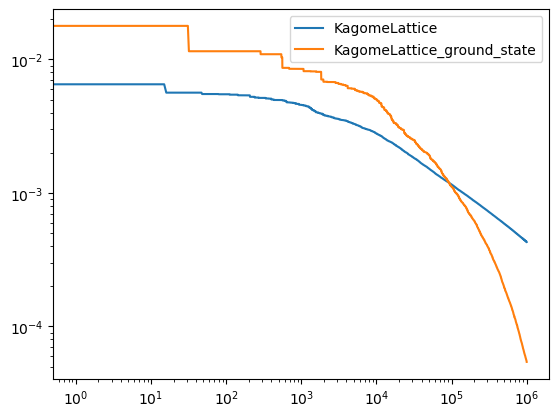

In [49]:
# make both axes log
terms = 1000000
plot_coeffs(system=HeisenbergJ1J2(
            KagomeLattice(width=2, height=4),
            J1=1,
            J2=1,
            use_symmetries=True,
            spin_inversion=1,
        ), terms=terms)

#plt.gca().set_yscale("log", base=10)
# plt.gca().set_xscale("log", base=10)
plt.gca().set_yscale("log", base=10)
plt.gca().set_xscale("log", base=10)
plt.legend()


2023-08-18 13:36:28.713 | DEBUG    | heisenberg_hamiltonians:__init__:482 - number_spins=24
2023-08-18 13:36:28.728 | DEBUG    | heisenberg_hamiltonians:__init__:492 - Symmetry group contains 48 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-18 13:36:28.800 | DEBUG    | heisenberg_hamiltonians:__init__:501 - Hilbert space dimension is 29394
2023-08-18 13:36:28.812 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-TriangleLattice6x4-1.0-1.3-True-1-1.pickle
2023-08-18 13:36:28.814 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:121 - Ground state energy is -62.7791847275
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-18 13:36:28.901 | DEBUG    | fast_boolean_analysis:fourier_expand:295 - Finding signal
2023-08-18 13:36:28.902 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_full_basis:212 - Finding coeffs
2023-08-18 13:36:28.903 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:234 - Finding basis_state_info
2023-08-18 13:36:30.146 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:2

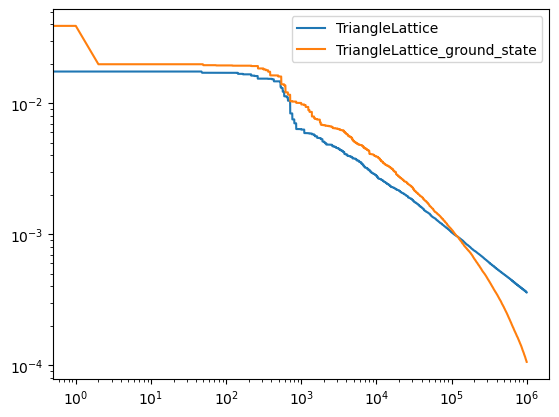

In [50]:
# make both axes log
plot_coeffs(
    system=HeisenbergJ1J2(
        TriangleLattice(width=6, height=4),
        J1=1,
        J2=1.3,
        use_symmetries=True,
        spin_inversion=1,
    ),
    terms=terms,
)
plt.gca().set_yscale("log", base=10)
plt.gca().set_xscale("log", base=10)
plt.legend()

In [16]:
signal = LBFFromSpinSystemGS(
    system=HeisenbergJ1J2(
        KagomeLattice(width=2, height=3),
        J1=1,
        J2=0.8,
        use_symmetries=True,
        spin_inversion=1,
    ),
    kind=SignSignalKind(),
)

fourier = fourier_expand(signal)

terms = fourier.how_many_terms_to_achieve_score(
    target_score=0.95, scorer="sign_overlap", min_terms=1, max_terms=101
)[0]

assert terms is not None

assert(
    fourier.truncate_orbitwise(keep_largest_n(terms)).prediction_score("sign_overlap")[0]
    >= 0.95
)
assert(
    fourier.truncate_orbitwise(keep_largest_n(terms - 1)).prediction_score("sign_overlap")[
        0
    ]
    < 0.95
)

number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102
Calculating eigenvalues / eigenstates


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Ground state energy is -29.4963743253
Calculating eigenvalues / eigenstates
Ground state energy is -29.4963743253
Finding basis_state_info
Finding corresp_repr_indices
Finding coeffs


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:189: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = (
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


In [11]:
terms

22

In [15]:
fourier.truncate_orbitwise(keep_largest_n(terms)).prediction_score("sign_overlap")[0]

0.9558522103560075

In [12]:

assert terms is not None

assert fourier.truncate(keep_largest_n(terms)).prediction_score("sign_overlap")[0] >= 0.95

assert fourier.truncate(keep_largest_n(terms - 1)).prediction_score("sign_overlap")[0] < 0.95



AssertionError: 

In [3]:
fourier = fourier_expand(signal, verbose=True)

Calculating signal value
Finding basis_state_info
Finding corresp_repr_indices
Finding coeffs
iteration 1.0 of 16.0
iteration 2.0 of 16.0
iteration 3.0 of 16.0
iteration 4.0 of 16.0
iteration 5.0 of 16.0
iteration 6.0 of 16.0
iteration 7.0 of 16.0
iteration 8.0 of 16.0
iteration 9.0 of 16.0
iteration 10.0 of 16.0
iteration 11.0 of 16.0
iteration 12.0 of 16.0
iteration 13.0 of 16.0
iteration 14.0 of 16.0
iteration 15.0 of 16.0
iteration 16.0 of 16.0


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:189: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = (


In [4]:
fourier.how_many_terms_to_achieve_score(0.7, scorer='accuracy')

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


(1,
 array([ 0.39276123,  0.39276123, -0.39276123, ..., -0.39276123,
         0.39276123,  0.39276123]))

In [15]:
lattice = SquareLattice(width=4, height=8)
signal = LBFFromSpinSystemGS(
    system=HeisenbergJ1J2(lattice, J1=1.0, J2=0.0, ground_state_cache_dir=Path("./groundstates")),
)


number_spins=32
Symmetry group contains 128 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2379208


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -87.8427875046
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x8-1.0-0.0-True-1-1.pickle
Ground state energy is -87.8427875046


In [16]:
fourier = fourier_expand(signal, verbose=True)

Calculating signal value


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:183: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = (


iteration 1.0 of 32.0


MemoryError: Unable to allocate 16.0 GiB for an array with shape (1, 2147483648, 1) and data type float64

In [5]:
get_scorer("f1")

<function lattice_boolean_analysis.f1_scorer(true: numpy.ndarray[typing.Any, numpy.dtype[+ScalarType]], predict: numpy.ndarray[typing.Any, numpy.dtype[+ScalarType]], prob: numpy.ndarray[typing.Any, numpy.dtype[+ScalarType]])>

In [7]:
fourier.how_many_terms_to_achieve_score(0.8, scorer="f1", max_terms=4)

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


In [9]:
fourier.truncate(keep_largest_n(1)).prediction_score("f1")

0.6529316467279155

In [13]:
np.argmax(fourier.coeffs)

195480038

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

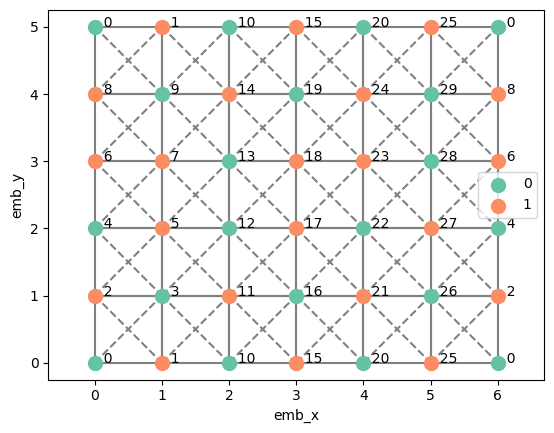

In [14]:
fourier.signal.lattice.plot(spins=195480038)